1. 밀원 공유 기반 꿀벌 네트워크 구성 함수

In [15]:
import pandas as pd
import numpy as np
import igraph as ig
from itertools import combinations
from sklearn.neighbors import BallTree

def build_bee_network_by_distance_and_shared_florals(df, distance_threshold_km=6):
    """
    거리 조건(6km)과 밀원 공유 조건을 모두 만족하는 꿀벌군집 간 엣지를 생성한 igraph 객체 반환

    Args:
        df (pd.DataFrame): 꿀벌군집 데이터. 'Latitude', 'Longitude', 'ID', 'nearby_x' 포함
        distance_threshold_km (float): 꿀벌군집 간 연결 허용 거리 (단위: km)

    Returns:
        igraph.Graph: 꿀벌군집 네트워크
    """
    df = df.copy()
    bee_coords = np.radians(df[["Latitude", "Longitude"]].values)
    tree = BallTree(bee_coords, metric='haversine')
    radius = distance_threshold_km / 6371.0  # km → radian

    # nearby 밀원 ID 컬럼 추출
    nearby_cols = [col for col in df.columns if col.startswith("nearby_")]
    bee_id_to_floral_set = {
        row["ID"]: set(row[nearby_cols].dropna().astype(int))
        for _, row in df.iterrows()
    }

    id_list = df["ID"].tolist()
    id_to_idx = {id_: i for i, id_ in enumerate(id_list)}
    edges = set()

    # 각 꿀벌군집 간 거리와 밀원 공유 여부를 함께 고려
    for i, id_i in enumerate(id_list):
        nearby_indices = tree.query_radius([bee_coords[i]], r=radius)[0]
        for j in nearby_indices:
            if i >= j:
                continue  # 중복 방지
            id_j = id_list[j]

            # 공통 밀원 있는 경우에만 연결
            shared_florals = bee_id_to_floral_set[id_i] & bee_id_to_floral_set[id_j]
            if shared_florals:
                edges.add((i, j))

    g = ig.Graph(edges=list(edges), directed=False)
    g.vs["ID"] = id_list
    return g


In [33]:
df = pd.read_csv("../../data/final/6_Apis_cerana_with_nearby6.csv")  # nearby_x 열 포함

g = build_bee_network_by_distance_and_shared_florals(df, distance_threshold_km=6)

print(g.summary())


IGRAPH U--- 1159 2932 -- 
+ attr: ID (v)


In [34]:
degree = g.degree()
betweenness = g.betweenness()


In [35]:
id_to_index = {v["ID"]: idx for idx, v in enumerate(g.vs)}
df["degree_centrality"] = df["ID"].map(lambda x: degree[id_to_index[x]] if x in id_to_index else np.nan)
df["betweenness_centrality"] = df["ID"].map(lambda x: betweenness[id_to_index[x]] if x in id_to_index else np.nan)


In [36]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 한글 폰트 설정 (필요 시 조정)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

def run_centrality_correlation_analysis(df, label="cerana", save_path=None):
    """
    중심성과 발생두수(감염 개체 수) 간의 Pearson 및 Spearman 상관 분석과 시각화

    Args:
        df (pd.DataFrame): 중심성 열 포함된 데이터프레임 ('degree_centrality', 'betweenness_centrality')
        label (str): 출력용 라벨
        save_path (str, optional): 저장 경로 (이미지 저장)
    """
    print(f"\n[{label}] 중심성과 감염 개체 수의 상관 분석")

    df_clean = df.dropna(subset=["발생두수", "degree_centrality", "betweenness_centrality"])

    # Pearson
    p_deg, pval_deg = pearsonr(df_clean["발생두수"], df_clean["degree_centrality"])
    p_btw, pval_btw = pearsonr(df_clean["발생두수"], df_clean["betweenness_centrality"])

    # Spearman
    s_deg, spval_deg = spearmanr(df_clean["발생두수"], df_clean["degree_centrality"])
    s_btw, spval_btw = spearmanr(df_clean["발생두수"], df_clean["betweenness_centrality"])

    # 결과 출력
    print(f"[Pearson] 발생두수 vs Degree: r = {p_deg:.4f}, p = {pval_deg:.4f}")
    print(f"[Pearson] 발생두수 vs Betweenness: r = {p_btw:.4f}, p = {pval_btw:.4f}")
    print(f"[Spearman] 발생두수 vs Degree: ρ = {s_deg:.4f}, p = {spval_deg:.4f}")
    print(f"[Spearman] 발생두수 vs Betweenness: ρ = {s_btw:.4f}, p = {spval_btw:.4f}")

    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.regplot(data=df_clean, x="degree_centrality", y="발생두수", ax=axes[0])
    axes[0].set_title(f"{label} - Degree 중심성과 발생두수")

    sns.regplot(data=df_clean, x="betweenness_centrality", y="발생두수", ax=axes[1])
    axes[1].set_title(f"{label} - Betweenness 중심성과 발생두수")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()



[cerana - 거리+밀원 기반] 중심성과 감염 개체 수의 상관 분석
[Pearson] 발생두수 vs Degree: r = -0.1283, p = 0.0000
[Pearson] 발생두수 vs Betweenness: r = -0.0398, p = 0.1757
[Spearman] 발생두수 vs Degree: ρ = -0.1546, p = 0.0000
[Spearman] 발생두수 vs Betweenness: ρ = -0.0246, p = 0.4023


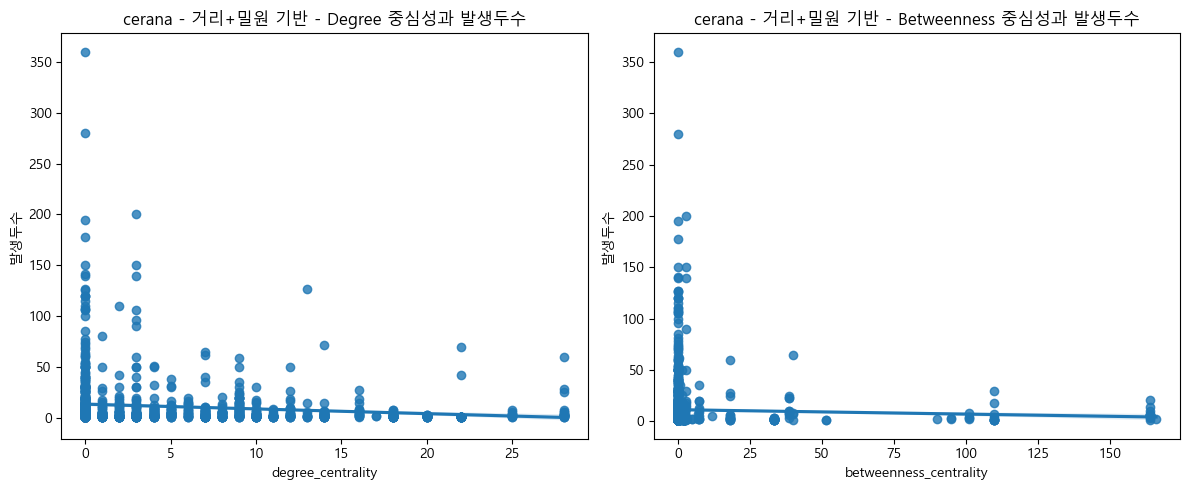

In [37]:
run_centrality_correlation_analysis(df, label="cerana - 거리+밀원 기반")
